In [2]:
("Task 4 :-Movie Rating Prediction With Python")

'Task 4 :-Movie Rating Prediction With Python'

In [3]:
import pandas as pd
import numpy as np


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [7]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [8]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
print(df.head())
print("\nDataset Info:")
print(df.info())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [9]:
df = df.dropna(subset=['Rating'])
categorical_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")


In [10]:
df['Duration'] = df['Duration'].str.replace(' min', '')

df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

df['Duration'] = df['Duration'].fillna(df['Duration'].median())

df['Votes'] = (
    df['Votes']
    .astype(str)
    .str.replace(',', '')
)

df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

df['Votes'] = df['Votes'].fillna(df['Votes'].median())


In [18]:
df['Year'] = df['Year'].astype(str)

df['Year'] = df['Year'].str.replace('(', '', regex=False)
df['Year'] = df['Year'].str.replace(')', '', regex=False)
df['Year'] = df['Year'].str.replace('-', '', regex=False)

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'] = df['Year'].fillna(df['Year'].median())

In [19]:
X = df[[
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3',
    'Duration',
    'Votes',
    'Year'
]]

y = df['Rating']

In [20]:
categorical_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

numeric_features = [
    'Duration',
    'Votes',
    'Year'
]

In [21]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [22]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [23]:
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [24]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred = pipeline.predict(X_test)

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"R2 Score : {r2:.2f}")


===== MODEL PERFORMANCE =====
Mean Absolute Error : 0.82
Mean Squared Error  : 1.18
Root Mean Squared Error : 1.09
R2 Score : 0.36


In [28]:
results = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': y_pred
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
       Actual Rating  Predicted Rating
9456             3.3          4.492598
14816            5.3          5.258190
3213             5.7          5.845403
3778             7.2          6.288147
5775             3.5          5.675651
12203            7.2          6.172701
12305            3.8          5.721095
4650             6.9          7.090326
8701             5.2          5.792091
4707             7.4          6.180670


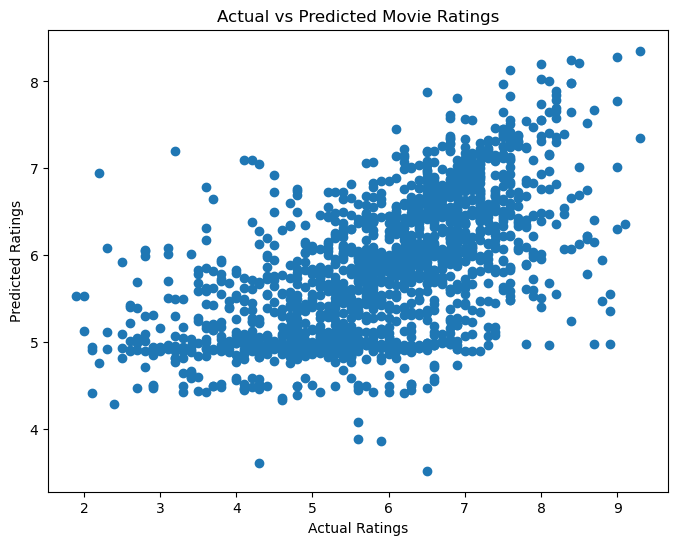

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

In [30]:
new_movie = pd.DataFrame({
    'Genre': ['Comedy'],
    'Director': ['Rajkumar Hirani'],
    'Actor 1': ['Aamir Khan'],
    'Actor 2': ['Kareena Kapoor'],
    'Actor 3': ['R. Madhavan'],
    'Duration': [160],
    'Votes': [50000],
    'Year': [2009]
})

predicted_rating = pipeline.predict(new_movie)

print("\nPredicted Movie Rating:", round(predicted_rating[0], 2))


Predicted Movie Rating: 7.74
